In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [2]:
with open('hazel_list.txt', 'r') as file:
    # .strip() removes spaces and \n characters, and we ignore empty lines
    my_gene_list = [line.strip() for line in file if line.strip()]

print(f"Successfully loaded {len(my_gene_list)} genes from hazel_list.txt.")

Successfully loaded 1238 genes from hazel_list.txt.


# cluster_rna_matrix

In [3]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


# filtered_meth_df

In [4]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [5]:
import statsmodels.api as sm
from scipy.stats import zscore

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


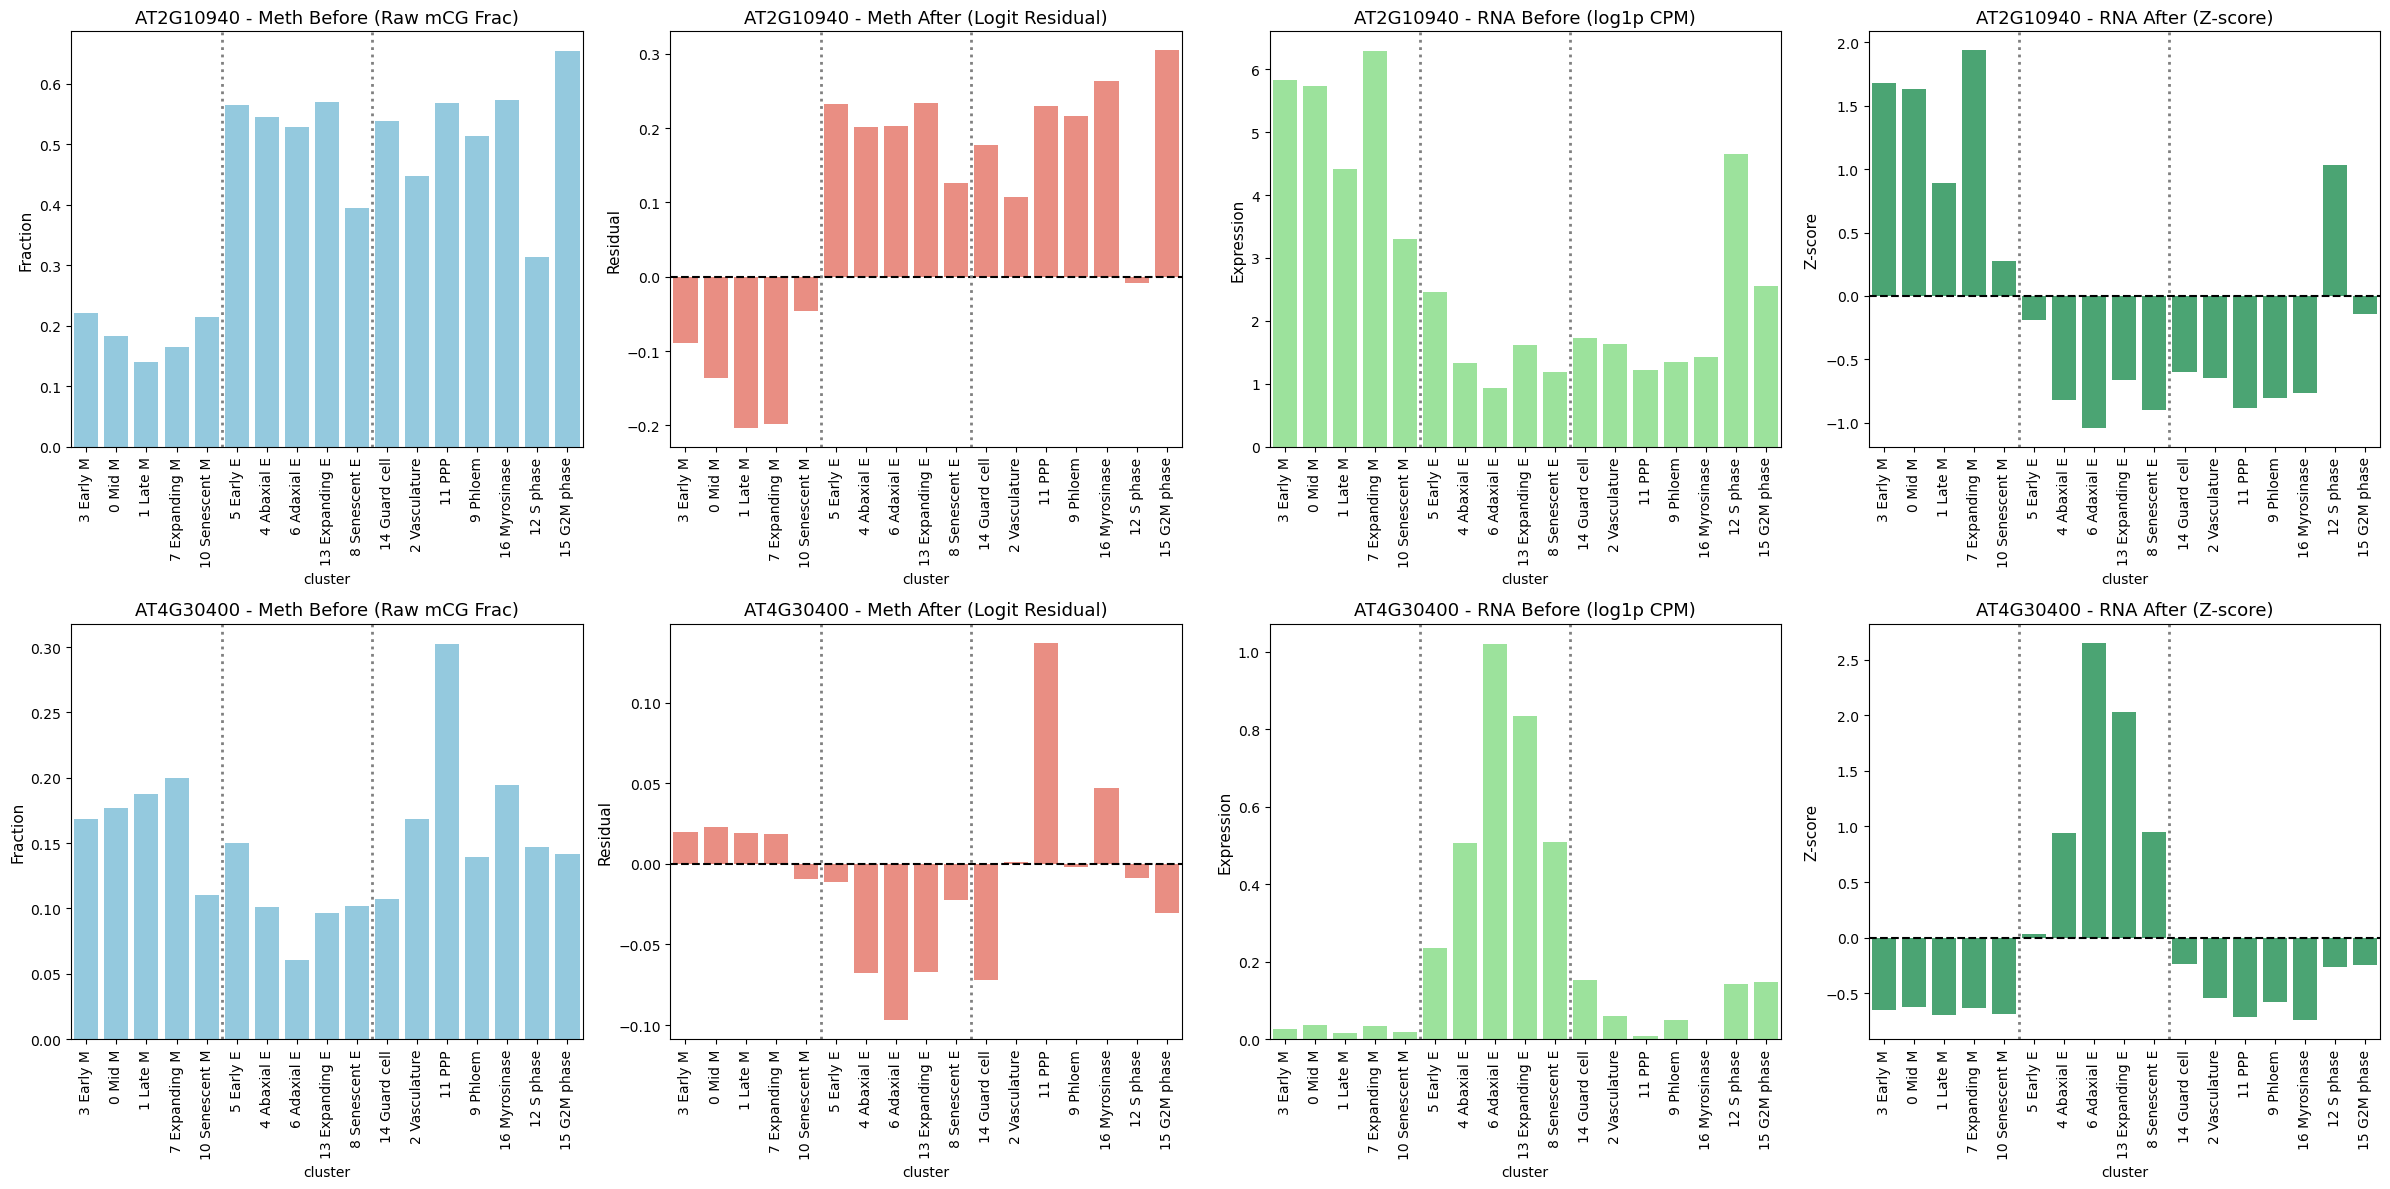

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore

genes_to_check = ['AT2G10940', 'AT4G30400']

# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '1 Late M', '7 Expanding M', '10 Senescent M',
    '5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

fig, axes = plt.subplots(len(genes_to_check), 4, figsize=(24, 6 * len(genes_to_check)))

if len(genes_to_check) == 1:
    axes = [axes]

for i, gene in enumerate(genes_to_check):
    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene].rename(index=cluster_mapping)
        meth_adj = adj_meth_matrix.loc[gene].rename(index=cluster_mapping)
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)
        
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene].rename(index=cluster_mapping)
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG Frac)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=90)
    
    # --- Panel 2: Methylation After ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=90)

    # --- Panel 3: RNA Before ---
    ax3 = axes[i, 2]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax3, color='lightgreen')
        ax3.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax3.set_ylabel("Expression", fontsize=11)
    else:
        ax3.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax3.tick_params(axis='x', rotation=90)

    # --- Panel 4: RNA After ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax4, color='mediumseagreen')
        ax4.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax4.set_ylabel("Z-score", fontsize=11)
        ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax4.tick_params(axis='x', rotation=90)

    # Add vertical dividers to separate cell types visually
    for ax in [ax1, ax2, ax3, ax4]:
        ax.axvline(4.5, color='gray', linestyle=':', lw=2) # Divider after Mesophyll
        ax.axvline(9.5, color='gray', linestyle=':', lw=2) # Divider after Epidermis

plt.tight_layout()
plt.show()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import zscore
from matplotlib.backends.backend_pdf import PdfPages

# -------------------------------------------------------------------
# 1) Put your previously identified gene groups here
#    Example format: cluster -> list of genes
# -------------------------------------------------------------------
gene_groups = {
    "14.0": [
        "AT3G59510", "AT1G16960", "AT1G23170", "AT3G58640", "AT5G02210",
        "AT5G39160", "AT5G42970", "AT1G68090", "AT3G26500", "AT2G14740"
    ],
    "13.0": [
        "AT4G38550", "AT5G39020", "AT3G14630", "AT5G48380", "AT5G38865",
        "AT3G57550", "AT2G39110", "AT2G26300", "AT5G17900", "AT2G34100"
    ],
    "12.0": [
        "AT2G29410", "AT5G09215", "AT5G64240", "AT4G15990", "AT5G64687",
        "AT5G43380", "AT1G23130", "AT4G16008", "AT2G21650", "ATMG01090"
    ],
    "7.0": [
        "AT2G23540", "AT1G64000", "AT1G52750", "AT1G47480", "AT2G05910",
        "AT1G24430", "AT4G17280", "AT1G09460", "AT4G16620", "AT4G01470"
    ],
    "10.0": [
        "AT2G07724", "AT2G06667", "ATMG00830", "AT3G02020", "AT2G29710",
        "AT1G04923", "AT5G14200", "AT2G14750", "AT1G64310", "AT2G24010"
    ],
    "3.0": [
        "AT2G05370", "AT1G11303", "AT2G15050", "AT1G32780", "AT3G09450",
        "AT1G62030", "AT5G38530", "AT2G33060", "AT1G29435", "AT3G26450"
    ],
    "8.0": [
        "AT5G28010", "AT2G14390", "AT5G08490", "AT1G31630", "AT2G21727",
        "AT3G18000", "AT4G11810", "AT4G01330", "AT5G01105", "AT4G00490"
    ],
    "1.0": [
        "AT3G04725", "AT2G07718", "AT5G05625", "AT2G40620", "AT5G59280",
        "AT3G42140", "AT1G20470", "AT1G30540", "AT1G19950", "AT3G14660"
    ],
    "11.0": [
        "AT5G34887", "AT1G79103", "AT2G21790", "AT1G80710", "AT3G08950",
        "AT1G22000", "AT3G19300", "AT4G22280", "AT1G59470", "AT4G27030"
    ]
}

# -------------------------------------------------------------------
# 2) Cluster mapping / order (same as your code)
# -------------------------------------------------------------------
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem',
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '1 Late M', '7 Expanding M', '10 Senescent M',
    '5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# -------------------------------------------------------------------
# 3) Output PDF
# -------------------------------------------------------------------
output_pdf = "gene_trends_report.pdf"

# -------------------------------------------------------------------
# 4) Helper to plot one gene on one page
# -------------------------------------------------------------------
def plot_gene_page(gene, group_name=None):
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene].rename(index=cluster_mapping)
        meth_adj = adj_meth_matrix.loc[gene].rename(index=cluster_mapping)
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)

    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene].rename(index=cluster_mapping)
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG Frac)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=90)

    # --- Panel 2: Methylation After ---
    ax2 = axes[1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    else:
        ax2.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax2.tick_params(axis='x', rotation=90)

    # --- Panel 3: RNA Before ---
    ax3 = axes[2]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax3, color='lightgreen')
        ax3.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax3.set_ylabel("Expression", fontsize=11)
    else:
        ax3.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax3.tick_params(axis='x', rotation=90)

    # --- Panel 4: RNA After ---
    ax4 = axes[3]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax4, color='mediumseagreen')
        ax4.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax4.set_ylabel("Z-score", fontsize=11)
        ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
    else:
        ax4.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax4.tick_params(axis='x', rotation=90)

    # --- Visual dividers ---
    for ax in axes:
        ax.axvline(4.5, color='gray', linestyle=':', lw=2)
        ax.axvline(9.5, color='gray', linestyle=':', lw=2)

    # --- Page title ---
    title = gene if group_"]
    \ame is None else f"{group_name} | {gene}"
    fig.suptitle(title, fontsize=16, y=1.02)

    return fig

# -------------------------------------------------------------------
# 5) Write all genes to a multipage PDF
# -------------------------------------------------------------------
with PdfPages(output_pdf) as pdf:
    for group_name, genes_to_check in gene_groups.items():
        for gene in genes_to_check:
            fig = plot_gene_page(gene, group_name=group_name)
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

print(f"Saved PDF to: {output_pdf}")

Saved PDF to: gene_trends_report.pdf
